---
---
---

<center>

# <b> IT3091 - Machine Learning <b> 
# <b> Lab Sheet 03 </b> 

#### Y3.S1.WD.AI.0101 
### IT24102699 - Mummullage B.U.T 

### <i> **Data Preprocessing and Transformation** </i> 

##### **Dataset** : Titanic Dataset

</center>

---
---
---

## **Part A - Data Cleaning**


### 1. Import the dataset by using, import seaborn as sns df = sns.load_dataset("titanic")


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the built-in titanic dataset from seaborn
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---


### 2. Identify the feature types in the dataset.


* Numerical features 
* Categorical features 
* Target variable 

In [2]:
print(df.dtypes)

# Filter columns by data type to separate numerical and categorical features
numerical_features = df.select_dtypes(include=["number"]).columns.tolist()
categorical_features = df.select_dtypes(exclude=["number"]).columns.tolist()

print(f"\nNumerical features: {numerical_features}")
print(f"Categorical features: {categorical_features}")

survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

Numerical features: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical features: ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


>### ***Answers***
>
> - **Numerical features:** `survived`, `pclass`, `age`, `sibsp`, `parch`, `fare`
>
> - **Categorical features:** `sex`, `embarked`, `class`, `who`, `adult_male`, `deck`, `embark_town`, `alive`, `alone`
>
> - **Target variable:** `survived` (or `alive`)

---


### 3. Check the dataset for missing values and duplicate records, Remove duplicate records if any.


In [3]:
# Check for null values in the dataset
print("Missing values per feature:\n", df.isnull().sum())

# Check for identical row records
print("\n\nNumber of duplicate records:", df.duplicated().sum())

# Drop the identical row records to clean the dataset
df = df.drop_duplicates()
print("\nNumber of duplicate records after removal:", df.duplicated().sum())

Missing values per feature:
 survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


Number of duplicate records: 107

Number of duplicate records after removal: 0


---
---

### 4. Identify the features containing missing values. Choose and justify an appropriate imputation method for each feature. Display the number of missing values before and after imputation.


In [4]:
missing_cols = df.columns[df.isnull().any()].tolist()
print("Features with missing values before imputation:\n", df[missing_cols].isnull().sum())

# Fill missing age values with the median to avoid outlier skewness
df["age"] = df["age"].fillna(df["age"].median())

# Fill missing embarked locations with the most frequent value (mode)
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

# Group missing deck values into a new 'Unknown' category to retain data
if df["deck"].dtype.name == "category" and "Unknown" not in df["deck"].cat.categories:
    df["deck"] = df["deck"].cat.add_categories("Unknown")
df["deck"] = df["deck"].fillna("Unknown")

print("\nMissing values after imputation:\n", df[missing_cols].isnull().sum())

Features with missing values before imputation:
 age            106
embarked         2
deck           582
embark_town      2
dtype: int64

Missing values after imputation:
 age            0
embarked       0
deck           0
embark_town    0
dtype: int64


>### ***Answers***
>
> - **`age`**: Numerical feature. We used **median** imputation because it is robust to outliers compared to the mean.
>
> - **`embarked` & `embark_town`**: Categorical features. We used **mode** (most frequent value) imputation which is the standard method for categorical data.
>
> - **`deck`**: Categorical feature with a very high percentage of missing values. We assigned a new category **'Unknown'** so we don't lose the remaining data by dropping it.


---
---

## **Part B – Categorical Data Encoding**


### 1. Identify, 

* Binary categorical features 

* Nominal categorical features 

* Ordinal categorical features 


In [5]:
# Group categorical column names by their appropriate encoding method
binary_cols = ["sex", "adult_male", "alone", "alive"]
nominal_cols = ["embarked", "embark_town", "who", "deck"]
ordinal_cols = ["class"]

>### ***Answers***
>
> - **Binary categorical features:** `sex`, `adult_male`, `alone`, `alive`
>
> - **Nominal categorical features:** `embarked`, `embark_town`, `who`, `deck`
>
> - **Ordinal categorical features:** `class` (First, Second, Third)

---


### 2. Apply and justify the most appropriate encoding technique for each categorical feature. Display the transformed dataset.

* Binary Encoding / Label Encoding 

* One-Hot Encoding 

* Ordinal Encoding (if applicable) 

In [6]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

df_encoded = df.copy()

# Apply LabelEncoder to convert binary features into 0 and 1
le = LabelEncoder()
for col in binary_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Apply OrdinalEncoder to preserve the natural order of the 'class' feature
ordinal_encoder = OrdinalEncoder(categories=[["Third", "Second", "First"]])
df_encoded[["class"]] = ordinal_encoder.fit_transform(df_encoded[["class"]])

# Apply One-Hot Encoding to nominal features to prevent false ordinality
df_encoded = pd.get_dummies(df_encoded, columns=nominal_cols, drop_first=True)

df_encoded.head()

,survived,pclass,sex,age,sibsp,parch,fare,class,adult_male,alive,...,embark_town_Southampton,who_man,who_woman,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,deck_Unknown
0,0,3,1,22.0,1,0,7.2500,0.0,1,0,...,True,True,False,False,False,False,False,False,False,True
1,1,1,0,38.0,1,0,71.2833,2.0,0,1,...,False,False,True,False,True,False,False,False,False,False
2,1,3,0,26.0,0,0,7.9250,0.0,0,1,...,True,False,True,False,False,False,False,False,False,True
3,1,1,0,35.0,1,0,53.1000,2.0,0,1,...,True,False,True,False,True,False,False,False,False,False
4,0,3,1,35.0,0,0,8.0500,0.0,1,0,...,True,True,False,False,False,False,False,False,False,True


>### ***Answers***
>
> - **Binary Features:** Used **Label Encoding**, converting them to 0s and 1s, since they only have two states.
>
> - **Ordinal Features:** Used **Ordinal Encoding**, mapping 'Third', 'Second', and 'First' to 0, 1, and 2 respectively, to preserve their meaningful order.
>
> - **Nominal Features:** Used **One-Hot Encoding**, creating dummy binary variables for each category, preventing the model from assuming any false order among the classes.

---
---

## **Part C – Feature Scaling**


### 1. Apply the following scaling techniques to the numerical features and display the transformed values. 

* StandardScaler 

* MinMaxScaler 

* RobustScaler


In [7]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

numerical_cols = ["age", "fare"]

# Apply StandardScaler to standardize features to mean 0 and variance 1
std_scaler = StandardScaler()
df_std = df_encoded.copy()
df_std[numerical_cols] = std_scaler.fit_transform(df_std[numerical_cols])

# Apply MinMaxScaler to scale features strictly between 0 and 1
min_max_scaler = MinMaxScaler()
df_min_max = df_encoded.copy()
df_min_max[numerical_cols] = min_max_scaler.fit_transform(df_min_max[numerical_cols])

# Apply RobustScaler to handle the extreme outliers in the fare feature
robust_scaler = RobustScaler()
df_robust = df_encoded.copy()
df_robust[numerical_cols] = robust_scaler.fit_transform(df_robust[numerical_cols])

print("StandardScaler outputs:")
print(df_std[numerical_cols].head())
print("\nMinMaxScaler outputs:")
print(df_min_max[numerical_cols].head())
print("\nRobustScaler outputs:")
print(df_robust[numerical_cols].head())

StandardScaler outputs:
        age      fare
0 -0.557360 -0.526825
1  0.608298  0.701587
2 -0.265945 -0.513876
3  0.389737  0.352760
4  0.389737 -0.511478

MinMaxScaler outputs:
        age      fare
0  0.271174  0.014151
1  0.472229  0.139136
2  0.321438  0.015469
3  0.434531  0.103644
4  0.434531  0.015713

RobustScaler outputs:
        age      fare
0 -0.446429 -0.331935
1  0.696429  2.125276
2 -0.160714 -0.306032
3  0.482143  1.427511
4  0.482143 -0.301235


---


### 2. Compare the outputs. 

* Which scaler produces values between 0 and 1?  

* Which scaler produces a mean close to 0?  

* Which scaling method would you recommend for this dataset? Explain. 

>### ***Answers***
>
> - **Which scaler produces values between 0 and 1?** `MinMaxScaler` produces values strictly between 0 and 1.
>
> - **Which scaler produces a mean close to 0?** `StandardScaler` standardizes features to have a mean of 0 and variance of 1.
>
> - **Which scaling method would you recommend for this dataset?** `RobustScaler` is highly recommended for the Titanic dataset, especially for the `fare` feature, because it contains significant outliers. `RobustScaler` is based on percentiles (IQR) and is not influenced by extreme values, unlike `StandardScaler` and `MinMaxScaler`.

---
---

## **Part D – Feature transformation**


### 1. Identify the skewed numerical features using the histograms.


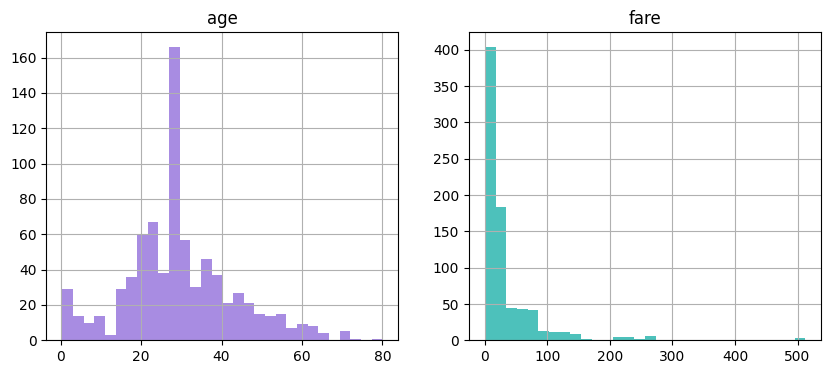

In [8]:
# Generate 30-bin histograms to visualize the data distribution of numerical features
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

df_encoded["age"].hist(bins=30, ax=axes[0], color="mediumpurple", alpha=0.8)
axes[0].set_title("age")

df_encoded["fare"].hist(bins=30, ax=axes[1], color="lightseagreen", alpha=0.8)
axes[1].set_title("fare")
plt.show()

>### ***Answers***
>
> Based on the histograms, the **`fare`** feature is highly right-skewed. The **`age`** feature is roughly normally distributed (especially after median imputation).


---


### 2. Apply an appropriate transformation to each skewed numerical feature and justify your choice.


In [9]:
# Use np.log1p to compress extreme fare values and normalize the right-skewed distribution
df_encoded["fare_log"] = np.log1p(df_encoded["fare"])

>### ***Answers***
>
> - **Transformation used:** Log Transformation (using `log1p`).
>
> - **Justification:** Log transformation effectively handles right-skewed data by compressing large values and expanding smaller ones, bringing the distribution closer to a normal distribution.

---


### 3. Compare the distributions before and after transformation.


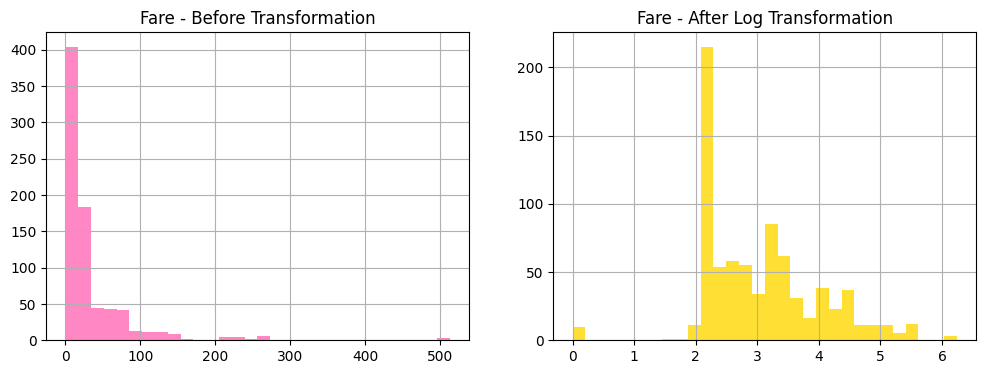

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot the original right-skewed fare column
df_encoded["fare"].hist(bins=30, ax=axes[0], color="hotpink", alpha=0.8)
axes[0].set_title("Fare - Before Transformation")

# Plot the log-transformed fare column for visual comparison
df_encoded["fare_log"].hist(bins=30, ax=axes[1], color="gold", alpha=0.8)
axes[1].set_title("Fare - After Log Transformation")

plt.show()

---
---

## **Part E – Case Study**


### A data analyst is preparing the Titanic dataset for a machine learning model. Before splitting the dataset into training and testing sets, the analyst performs missing value imputation and feature scaling using the entire dataset. Another analyst follows the recommended workflow by first splitting the dataset into training and testing sets, then fitting the preprocessing methods using only the training dataset before transforming both datasets. 

### Answer the following questions:


> ### **1. What is the main difference between the two preprocessing workflows?**
> - The first workflow applies preprocessing (like finding the median for imputation or the mean for scaling) on the *entire dataset* before splitting it.
>
> - The second workflow correctly splits the data first, calculates the preprocessing statistics *only on the training set*, and then uses those fitted tools to transform both the training and testing sets.

> ### **2. Which workflow introduces data leakage?**
> - The first workflow introduces data leakage. By preprocessing the entire dataset, information from the testing set (like the overall mean or median) 'leaks' into the training process.

> ### **3. Why preprocessing methods should be fitted only on the training dataset?**
> - The testing dataset is meant to simulate unseen, real-world data. If we fit preprocessing tools on the test set, we are letting the model gain knowledge about the test data's distribution, leading to overly optimistic and biased performance evaluations. 

> ### **4. Which workflow would you recommend for building a reliable machine learning model? Justify your answer.**
> - The **second workflow** is recommended. Splitting the data *before* preprocessing ensures the test set remains completely unseen and independent. This prevents data leakage and ensures the model's evaluation metrics accurately reflect how it will perform on new, unobserved data.

---
---
---